In [67]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module
import cbmaps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib import rcParams
import matplotlib.font_manager as fm


import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox


In [2]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

stages = utils.stages
stage_colors = {key: value['color'] for key, value in stages.items()}
stage_labels = {key: value['label'] for key, value in stages.items()}
stage_markers = {key: value['marker'] for key, value in stages.items()}
stage_duration = {key: value['duration'] for key, value in stages.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}


In [3]:
def load_custom_font(variant="Light"):
    """Load the specified Aptos font variant."""
    font_path = f"/Library/Fonts/Aptos-{variant}.ttf"
    try:
        aptos_font = fm.FontProperties(fname=font_path)
        print(f"Using font: {aptos_font.get_name()}")
        return aptos_font
    except Exception as e:
        print(f"Error loading font: {e}")
        return None  # Return None if font loading fails


def add_stage_rectangles(ax, stages, font):
    """Add stage rectangles and labels to the axes."""
    for i, (stage, info) in enumerate(stages.items()):
        # Create a colored rectangle for each stage
        rect = Rectangle((i * 2, 0.4), width=1.5, height=0.5, color=info['color'])
        ax.add_patch(rect)

        # Add the stage label and duration inside the rectangle
        ax.text(
            i * 2 + 0.75, 0.65, 
            f"{info['label']}\n({info['duration']})",
            va='center', ha='center', fontsize=40, fontproperties=font, color='white'
        )


def add_arrows_between_stages(ax, num_stages):
    """Add arrows between consecutive stages."""
    for i in range(num_stages - 1):
        arrow = FancyArrowPatch(
            (i * 2 + 1.5, 0.65), ((i + 1) * 2, 0.65),
            arrowstyle='->,head_width=0.5,head_length=0.7', linewidth=7,
            mutation_scale=25, color='black'
        )
        ax.add_patch(arrow)


def configure_and_save_plot(num_stages, save_path=None):
    """Configure plot layout and save if a path is provided."""
    fig, ax = plt.subplots(figsize=(num_stages * 4, 4))
    ax.set_xlim(0, num_stages * 2)
    ax.set_ylim(0, 1)
    ax.axis('off')  # Hide axes

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    return fig, ax

In [4]:
def plot_lifecycle_key(stages, font_variant="Light", save_path=None):
    """Main function to generate the lifecycle key."""
    # Load the custom font (or fallback to default)
    font = load_custom_font(font_variant)
    if font is None:
        print("Using default font as fallback.")

    num_stages = len(stages)

    # Configure plot
    fig, ax = configure_and_save_plot(num_stages)

    # Add stage rectangles and labels
    add_stage_rectangles(ax, stages, font)

    # Add arrows between stages
    add_arrows_between_stages(ax, num_stages)

    # Refresh and render the canvas to avoid blank outputs
    fig.canvas.draw()

    # Save the plot with a transparent background if a save path is provided
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)
        print(f"Saved lifecycle key to {save_path}")

    # Display the plot
    plt.show()

Using font: Aptos
Saved lifecycle key to Fig-Lib/lifecycle_key.png


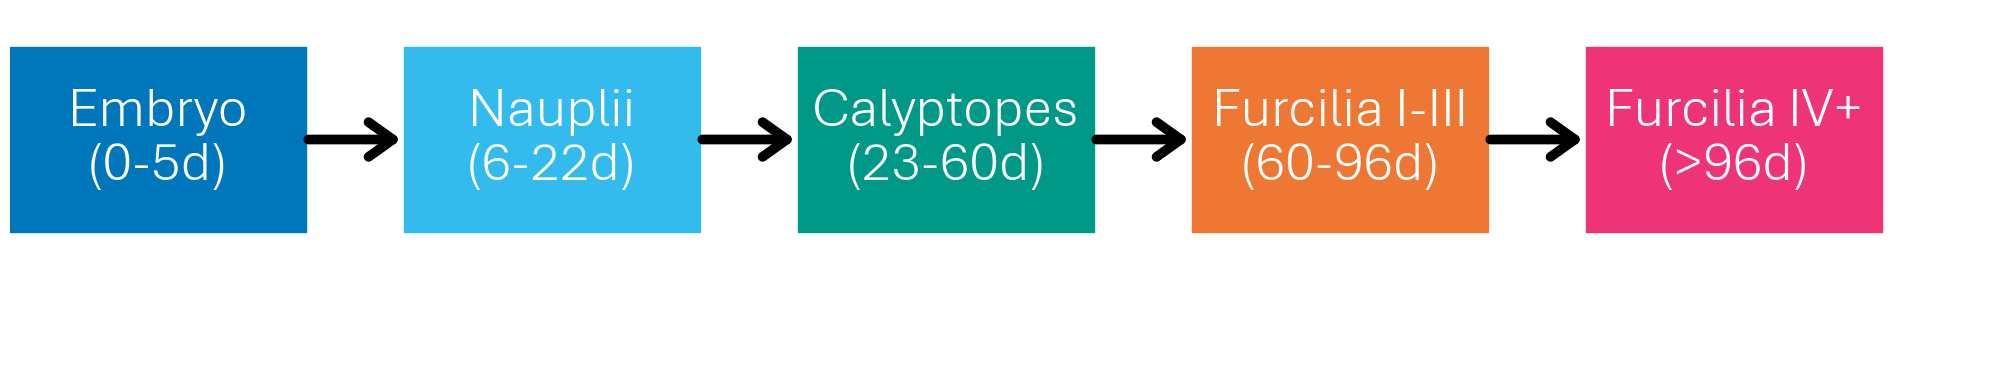

In [76]:
plot_lifecycle_key(stages, save_path="Fig-Lib/lifecycle_key.png")

# Vertical Depth Profiles

In [6]:
# Define the stage hour ranges for the full 180-day profile
stage_hour_ranges = {
    0: (0, 120),         # Embryo: 0–120 hours (0–5 days)
    1: (121, 528),       # Nauplii: 121–528 hours (6–22 days)
    2: (529, 1440),      # Calyptopes: 529–1440 hours (23–60 days)
    3: (1441, 2304),     # Furcilia I–III: 1441–2304 hours (61–96 days)
    4: (2303, 4320)      # Furcilia IV+: 2305–4320 hours (97–180 days)
}

Rules:
1.	Daytime Depth (Sunrise to Sunset):
	
    •	Add downward velocity until -150 m is reached.
	•	Stop descending once the depth is -150 m.

3.	Nighttime Depth (Sunset to Sunrise):
	
    •	Add upward velocity until -1.5 m is reached.
	•	Stop ascending once the depth is -1.5 m.


5.	Hourly Time Steps:
	
    •	Depths are calculated for every hour, stored in an array.

In [144]:
# Sunrise and sunset times for March 15 at three locations
sunrise_sunset_times = {
    "elephant_island": {"sunrise": 5 + 30 / 60, "sunset": 18 + 10 / 60},  # Times in hours
    "palmer_station": {"sunrise": 7, "sunset": 19 + 45 / 60},
    "adelaide_island": {"sunrise": 7 + 15 / 60, "sunset": 20 + 15 / 60},
}

In [146]:
sunrise_sunset_times['palmer_station']

{'sunrise': 7, 'sunset': 19.75}

In [56]:
def generate_vertical_profile_standard_dvm(duration=180):
    release_depth = -5  # Initial release depth (m)
    sinking_rate = 145 / 24  # m/hour (converted from 145 m/day)
    initial_sinking_time = 120  # Hours (5 days * 24 hours)
    ascent_rate = 68.2 / 24  # m/hour (converted from 68.2 m/day)
    dvm_start_hour = 63 * 24  # DVM starts at 63 days (converted to hours)

    # DVM parameters
    dvm_velocity = 0.016 * 3600  # m/hour (converted from 0.016 m/s)
    sunrise_hour = sunrise_palmer_mar15
    sunset_hour = sunset_palmer_mar15

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Current hour of the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Downward
            depths[hour] = max(depths[hour - 1] - dvm_velocity, -150)
        else:  # Nighttime: Upward
            depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)

    return hours, depths

In [147]:
def generate_vertical_profile_standard_dvm(duration=180, location=None):
    """
    Generates the vertical profile for standard DVM using location-based sunrise/sunset times.

    Parameters:
    - duration: Simulation duration in days.
    - location: A dictionary containing sunrise and sunset times for a specific location.

    Returns:
    - hours: Time in hours.
    - depths: Depths corresponding to each time step.
    """
    if location is None or "sunrise" not in location or "sunset" not in location:
        raise ValueError("A valid location dictionary with 'sunrise' and 'sunset' keys must be provided.")

    release_depth = -5  # Initial release depth (m)
    sinking_rate = 145 / 24  # m/hour (converted from 145 m/day)
    initial_sinking_time = 120  # Hours (5 days * 24 hours)
    ascent_rate = 68.2 / 24  # m/hour (converted from 68.2 m/day)
    dvm_start_hour = 63 * 24  # DVM starts at 63 days (converted to hours)

    # DVM parameters
    dvm_velocity = 0.016 * 3600  # m/hour (converted from 0.016 m/s)
    sunrise_hour = location["sunrise"]
    sunset_hour = location["sunset"]

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Current hour of the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Downward
            depths[hour] = max(depths[hour - 1] - dvm_velocity, -150)
        else:  # Nighttime: Upward
            depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)

    return hours, depths

In [150]:
def plot_vertical_profile(hours, depths, stage_colors, stage_hour_ranges, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_title("Standard Descent-Ascent Cycle with Standard DVM Pattern (Hours)", fontsize=16)

    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        start_idx = max(0, np.searchsorted(hours, start_hour))
        end_idx = min(len(hours), np.searchsorted(hours, end_hour))

        ax.plot(
            hours[start_idx:end_idx], depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({start_hour}-{end_hour} h)"
        )

    # # Add a horizontal line for the max DVM depth
    # ax.hlines(
    #     y=-150, xmin=dvm_start_hour, xmax=hours[-1],
    #     colors='gray', linestyles='dashed', linewidth=2, label='Max DVM Depth'
    # )

    # Add annotations for stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        midpoint_hour = (start_hour + end_hour) / 2
        ax.annotate(
            stages[stage]['label'],
            xy=(midpoint_hour, -200),  # Position below DVM depth for visibility
            fontsize=12, ha='center', color=stage_colors[stage]
        )

    # Set axis labels
    ax.set_xlabel('Time (hours)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Invert the y-axis so 0 m (surface) is at the top
    ax.set_ylim(-800, 5)
    ax.set_xlim(0, hours[-1])

    # Add legend
    ax.legend(loc='best', title='Life Stages', fontsize=10)

    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

In [149]:
# Select a location
location = sunrise_sunset_times["palmer_station"]

# Generate the profile
hours, depths = generate_vertical_profile_standard_dvm(duration=180, location=location)

# # Example: Print first 10 hours and depths
# for h, d in zip(hours[:10], depths[:10]):
#     print(f"Hour: {h}, Depth: {d}")

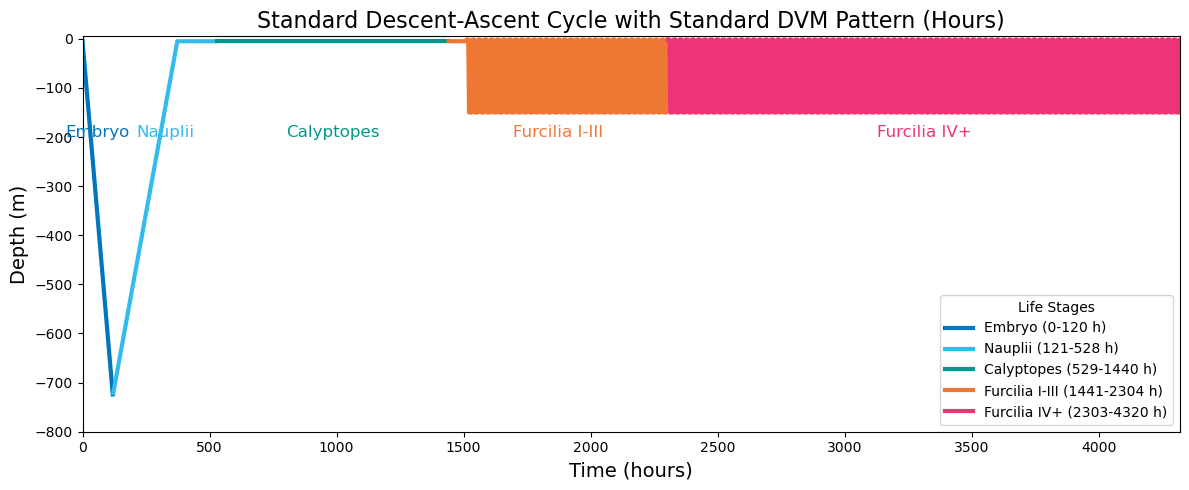

In [151]:

# Example without saving:
plot_vertical_profile(hours, depths, stage_colors, stage_hour_ranges)

# # Example with saving:
# plot_vertical_profile(hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, save_path="standard_depth_profile.png")

In [152]:
def plot_vertical_profile_daily(hours, depths, stage_colors, stage_hour_ranges, save_path=None):
    """
    Plots the vertical profile with daily labels on the x-axis.
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_title("Standard Descent-Ascent Cycle with Standard DVM Pattern (Days)", fontsize=16)

    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        start_idx = max(0, np.searchsorted(hours, start_hour))
        end_idx = min(len(hours), np.searchsorted(hours, end_hour))

        ax.plot(
            hours[start_idx:end_idx] / 24,  # Convert hours to days
            depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
        )

    # Set axis labels
    ax.set_xlabel('Time (days)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Invert the y-axis so 0 m (surface) is at the top
    ax.set_ylim(-800, 5)
    ax.set_xlim(0, hours[-1] / 24)  # Convert x-axis limit to days

    # Set x-axis ticks for daily intervals
    num_days = int(hours[-1] / 24)
    ax.set_xticks(range(0, num_days + 1, 25))  # Set ticks every 5 days

    # Add legend
    ax.legend(loc='best', title='Life Stages', fontsize=10)

    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

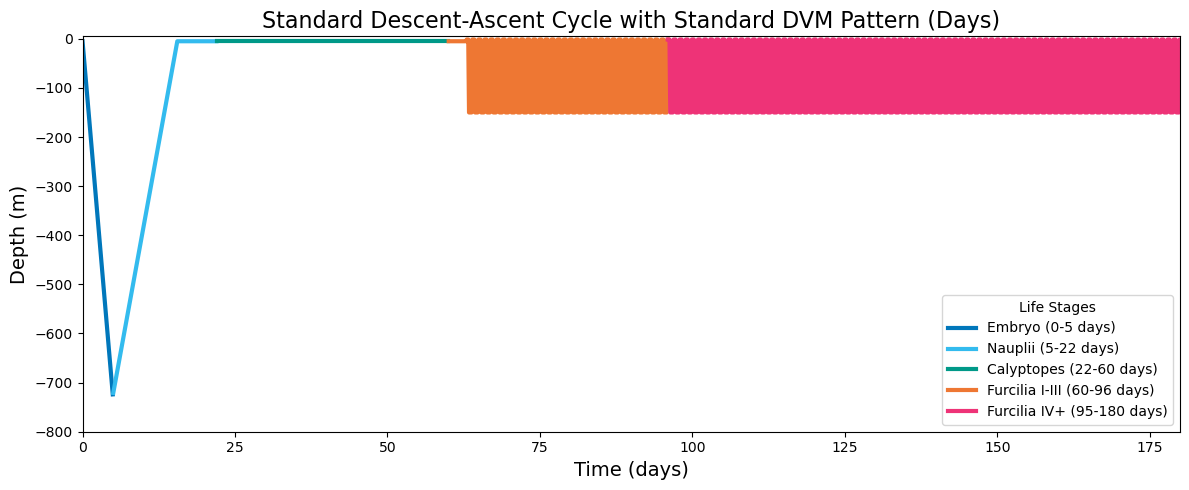

In [153]:
plot_vertical_profile_daily(hours, depths, stage_colors, stage_hour_ranges)

In [73]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

In [127]:
import matplotlib.image as mpimg

def plot_vertical_profile_daily_with_embedded_key(
    hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, stages,
    key_image_path, save_path=None
):
    """
    Plots the vertical profile with daily labels and embeds a lifecycle key image in the lower right corner.
    
    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - dvm_start_hour: starting hour for DVM.
    - stages: lifecycle stages dictionary.
    - key_image_path: path to the lifecycle key image (PNG or JPG).
    - save_path: optional path to save the final plot.
    """
    # Use constrained_layout for better handling of insets
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    ax.set_title("Standard Descent-Ascent Cycle with Standard DVM Pattern", fontsize=16)

    # Plot segments of the line with different colors based on life stages
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        start_idx = max(0, np.searchsorted(hours, start_hour))
        end_idx = min(len(hours), np.searchsorted(hours, end_hour))

        ax.plot(
            hours[start_idx:end_idx] / 24,  # Convert hours to days
            depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({int(start_hour/24)}-{int(end_hour/24)} days)"
        )

    # Set axis labels
    ax.set_xlabel("Time (days)", fontsize=14)
    ax.set_ylabel("Depth (m)", fontsize=14)

    # Invert the y-axis so 0 m (surface) is at the top
    ax.set_ylim(-800, 5)
    ax.set_xlim(0, hours[-1] / 24)  # Convert x-axis limit to days

    # Set x-axis ticks for daily intervals
    num_days = int(hours[-1] / 24)
    ax.set_xticks(range(0, num_days + 1, 25))  # Set ticks every 25 days

    # Embed the lifecycle key image in the lower right
    inset_ax = inset_axes(ax, width="75%", height="37%", loc="lower right", borderpad=0)
    inset_ax.axis("off")  # Turn off axes for the inset

    # Load and display the lifecycle key image
    img = mpimg.imread(key_image_path)
    inset_ax.imshow(img)
    inset_ax.set_aspect("auto")  # Ensure the image scales properly

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to Fig-Lib/standard-descent-ascent-schematic.png


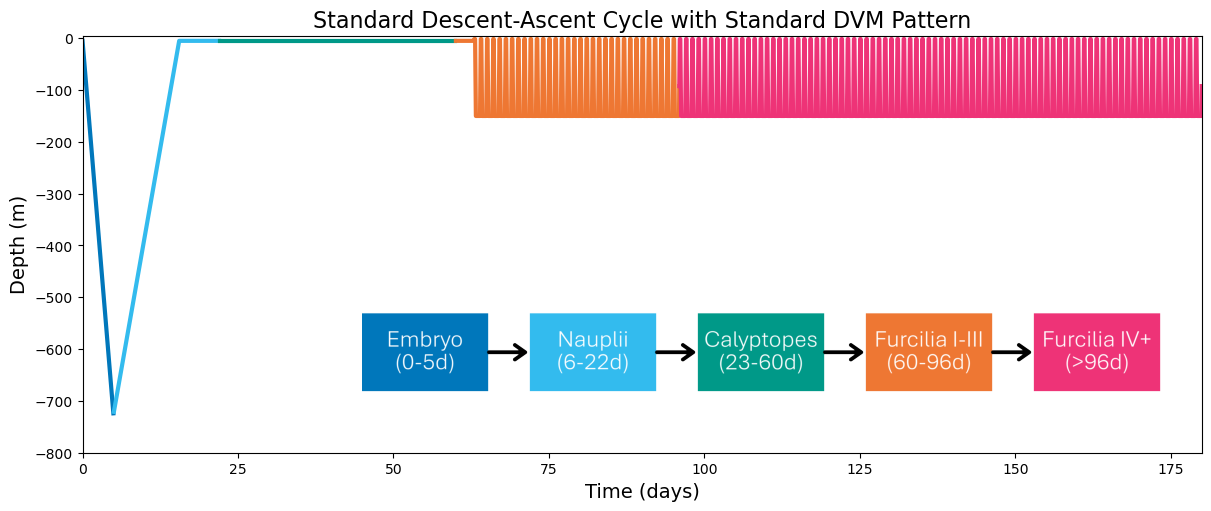

In [128]:
key_image_path = 'Fig-Lib/lifecycle_key.png'

plot_vertical_profile_daily_with_embedded_key(
    hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, stages,
    key_image_path=key_image_path, save_path='Fig-Lib/standard-descent-ascent-schematic.png'
)

# Zoom in to DVM Pattern

In [47]:
def dvm_zoom(hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, 
             zoom_xlim=(95 * 24, 105 * 24), zoom_ylim=(-250, 5), 
             sunrise_hour=4, sunset_hour=22 + 45 / 60, save_path=None):
    """
    Plots a zoomed-in view of the DVM pattern with day/night shading.

    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - dvm_start_hour: starting hour for DVM.
    - zoom_xlim: tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: tuple (min_depth, max_depth) for the y-axis zoom.
    - sunrise_hour: hour when the sun rises.
    - sunset_hour: hour when the sun sets.
    - save_path: optional path to save the figure.
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title('"Normal DVM" Schematic', fontsize=16)

    # Determine night blocks within the zoom_xlim
    start_hour = int(zoom_xlim[0])
    end_hour = int(zoom_xlim[1])
    current_block_start = None

    for hour in range(start_hour, end_hour):
        day_fraction = hour % 24  # Hour within the day
        if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
            if current_block_start is None:
                current_block_start = hour  # Start of a night block
        else:  # Daytime
            if current_block_start is not None:
                ax.axvspan(current_block_start, hour, color='lightblue', alpha=0.3)  # End the night block
                current_block_start = None

    # If there's an ongoing night block at the end, close it
    if current_block_start is not None:
        ax.axvspan(current_block_start, end_hour, color='lightblue', alpha=0.3)

    # Plot the DVM phase (from dvm_start_hour onward)
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
            continue
        
        start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
        end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

        ax.plot(
            hours[start_idx:end_idx], depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({start_hour}-{end_hour} h)"
        )
   
    # Set zoomed axis limits
    ax.set_xlim(zoom_xlim)
    ax.set_ylim(zoom_ylim)
    # Remove x-axis ticks and labels
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Set axis labels
    ax.set_xlabel('Time (hours)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Add legend
    night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=' "Night" (10:45PM - 4:00 AM)')
    ax.legend(loc='best', title='Life Stages', fontsize=10)
    ax.legend(handles=[night_patch], loc='lower left', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to zoomed_dvm_standard.png


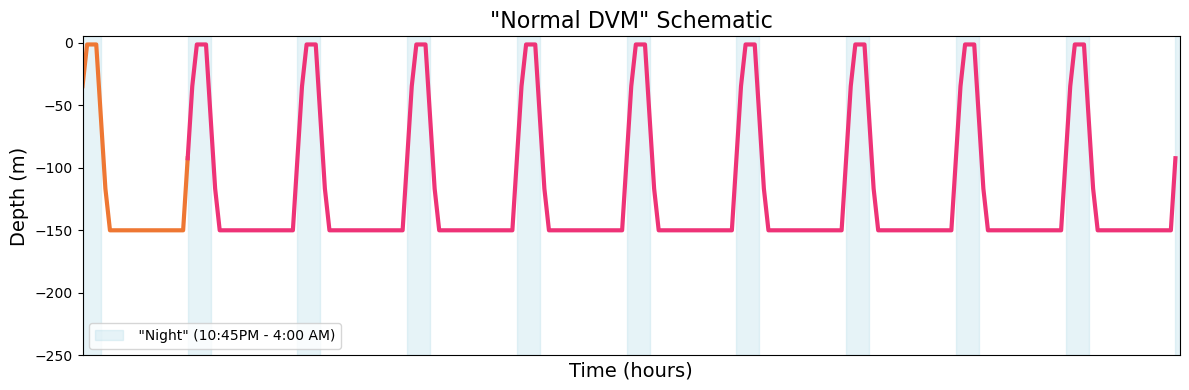

In [49]:
# Define zoom limits in hours
zoom_xlim = (95 * 24, 105 * 24)  # From day 95 to day 105, in hours
zoom_ylim = (-250, 5)            # Focus on depths between -250 m and 5 m

# Plot the zoomed DVM pattern with day/night shading
dvm_zoom(
    hours, depths, stage_colors, stage_hour_ranges, 
    dvm_start_hour=dvm_start_hour, zoom_xlim=zoom_xlim, zoom_ylim=zoom_ylim,
    save_path="zoomed_dvm_standard.png"

)

# Reversed DVM

In [154]:
def generate_vertical_profile_reverse_dvm(duration=180):
    release_depth = -5  # Initial release depth (5 meters below the surface)
    sinking_rate = 145 / 24  # m/hour
    initial_sinking_time = 120  # Hours (5 days)
    ascent_rate = 68.2 / 24  # m/hour
    dvm_start_hour = 63 * 24  # DVM starts at 63 days (converted to hours)

    # Reverse DVM parameters
    reverse_dvm_velocity = 0.016 * 3600  # m/hour (converted from 0.016 m/s)
    max_reverse_dvm_depth = -200  # Max depth during DVM in reverse DVM
    min_reverse_dvm_depth = -20  # Min depth during reverse DVM
    sunrise_hour = 4  # 4:00 AM
    sunset_hour = 22 + 45 / 60  # 10:45 PM

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: Reverse DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Hour within the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Move upward
            if depths[hour - 1] < -1.5:
                depths[hour] = min(depths[hour - 1] + reverse_dvm_velocity, -1.5)
            else:
                depths[hour] = -1.5  # Clamp depth at surface limit
        else:  # Nighttime: Move downward
            if depths[hour - 1] > min_reverse_dvm_depth:
                depths[hour] = max(depths[hour - 1] - reverse_dvm_velocity, min_reverse_dvm_depth)
            else:
                depths[hour] = min_reverse_dvm_depth  # Clamp depth at 20 m

    return hours, depths

In [155]:
def generate_vertical_profile_deep_dvm(duration=180):
    release_depth = -5  # Initial release depth (m)
    sinking_rate = 145 / 24  # m/hour (converted from 145 m/day)
    initial_sinking_time = 120  # Hours (5 days * 24 hours)
    ascent_rate = 68.2 / 24  # m/hour (converted from 68.2 m/day)
    dvm_start_hour = 63 * 24  # DVM starts at 63 days (converted to hours)

    # DVM parameters
    dvm_velocity = 0.016 * 3600  # m/hour (converted from 0.016 m/s)
    sunrise_hour = 4  # 4:00 AM
    sunset_hour = 22 + 45 / 60  # 10:45 PM

    # Initialize time and depth arrays
    hours = np.arange(duration * 24)  # Total duration in hourly intervals
    depths = np.full_like(hours, release_depth, dtype=float)  # Start at release depth

    # Phase 1: Initial Sinking (0–120 hours)
    for hour in range(initial_sinking_time):
        depths[hour] = max(release_depth - hour * sinking_rate, -800)

    # Phase 2: Ascent (121–1512 hours)
    ascent_start = initial_sinking_time
    for hour in range(ascent_start, dvm_start_hour):
        depths[hour] = min(depths[ascent_start - 1] + (hour - ascent_start) * ascent_rate, release_depth)

    # Phase 3: DVM (1512–4320 hours)
    for hour in range(dvm_start_hour, duration * 24):
        day_fraction = hour % 24  # Current hour of the day

        if sunrise_hour <= day_fraction < sunset_hour:  # Daytime: Downward
            depths[hour] = max(depths[hour - 1] - dvm_velocity, -200)
        else:  # Nighttime: Upward
            depths[hour] = min(depths[hour - 1] + dvm_velocity, -1.5)

    return hours, depths

In [100]:
# Generate the profile
hours_r, depths_r = generate_vertical_profile_reverse_dvm(duration=180)

# Generate the profile
hours_d, depths_d = generate_vertical_profile_deep_dvm(duration=180)


In [106]:
def reverse_dvm_zoom(hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, 
             zoom_xlim=(95 * 24, 105 * 24), zoom_ylim=(-250, 5), 
             sunrise_hour=4, sunset_hour=22 + 45 / 60, save_path=None):
    """
    Plots a zoomed-in view of the DVM pattern with day/night shading.

    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - dvm_start_hour: starting hour for DVM.
    - zoom_xlim: tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: tuple (min_depth, max_depth) for the y-axis zoom.
    - sunrise_hour: hour when the sun rises.
    - sunset_hour: hour when the sun sets.
    - save_path: optional path to save the figure.
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title('"Reversed DVM" Schematic', fontsize=16)

    # Determine night blocks within the zoom_xlim
    start_hour = int(zoom_xlim[0])
    end_hour = int(zoom_xlim[1])
    current_block_start = None

    for hour in range(start_hour, end_hour):
        day_fraction = hour % 24  # Hour within the day
        if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
            if current_block_start is None:
                current_block_start = hour  # Start of a night block
        else:  # Daytime
            if current_block_start is not None:
                ax.axvspan(current_block_start, hour, color='lightblue', alpha=0.3)  # End the night block
                current_block_start = None

    # If there's an ongoing night block at the end, close it
    if current_block_start is not None:
        ax.axvspan(current_block_start, end_hour, color='lightblue', alpha=0.3)

    # Plot the DVM phase (from dvm_start_hour onward)
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
            continue
        
        start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
        end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

        ax.plot(
            hours[start_idx:end_idx], depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({start_hour}-{end_hour} h)"
        )
   
    # Set zoomed axis limits
    ax.set_xlim(zoom_xlim)
    ax.set_ylim(zoom_ylim)
    # Remove x-axis ticks and labels
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Set axis labels
    ax.set_xlabel('Time (hours)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Add legend
    night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=' "Night" (10:45PM - 4:00 AM)')
    ax.legend(loc='best', title='Life Stages', fontsize=10)
    ax.legend(handles=[night_patch], loc='lower left', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to zoomed_dvm_reversed.png


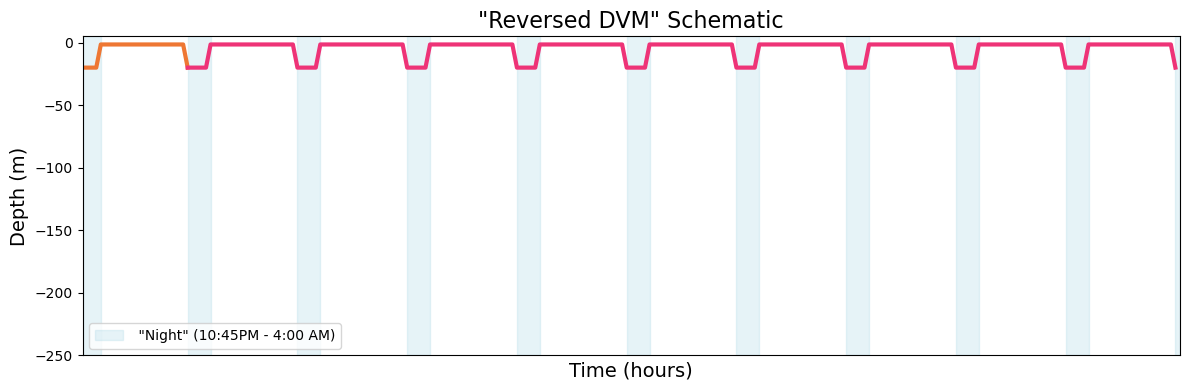

In [107]:
# Define zoom limits in hours
zoom_xlim = (95 * 24, 105 * 24)  # From day 95 to day 105, in hours
zoom_ylim = (-250, 5)            # Focus on depths between -250 m and 5 m

# Plot the zoomed DVM pattern with day/night shading
reverse_dvm_zoom(
    hours_r, depths_r, stage_colors, stage_hour_ranges, 
    dvm_start_hour=dvm_start_hour, zoom_xlim=zoom_xlim, zoom_ylim=zoom_ylim,
    save_path="zoomed_dvm_reversed.png"

)

In [108]:
def deep_dvm_zoom(hours, depths, stage_colors, stage_hour_ranges, dvm_start_hour, 
             zoom_xlim=(95 * 24, 105 * 24), zoom_ylim=(-250, 5), 
             sunrise_hour=4, sunset_hour=22 + 45 / 60, save_path=None):
    """
    Plots a zoomed-in view of the DVM pattern with day/night shading.

    Parameters:
    - hours: array of time in hours.
    - depths: array of depths corresponding to hours.
    - stage_colors: dictionary of stage colors.
    - stage_hour_ranges: dictionary of stage hour ranges.
    - dvm_start_hour: starting hour for DVM.
    - zoom_xlim: tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: tuple (min_depth, max_depth) for the y-axis zoom.
    - sunrise_hour: hour when the sun rises.
    - sunset_hour: hour when the sun sets.
    - save_path: optional path to save the figure.
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_title('"Deep DVM" Schematic', fontsize=16)

    # Determine night blocks within the zoom_xlim
    start_hour = int(zoom_xlim[0])
    end_hour = int(zoom_xlim[1])
    current_block_start = None

    for hour in range(start_hour, end_hour):
        day_fraction = hour % 24  # Hour within the day
        if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
            if current_block_start is None:
                current_block_start = hour  # Start of a night block
        else:  # Daytime
            if current_block_start is not None:
                ax.axvspan(current_block_start, hour, color='lightblue', alpha=0.3)  # End the night block
                current_block_start = None

    # If there's an ongoing night block at the end, close it
    if current_block_start is not None:
        ax.axvspan(current_block_start, end_hour, color='lightblue', alpha=0.3)

    # Plot the DVM phase (from dvm_start_hour onward)
    for stage, (start_hour, end_hour) in stage_hour_ranges.items():
        if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
            continue
        
        start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
        end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

        ax.plot(
            hours[start_idx:end_idx], depths[start_idx:end_idx],
            color=stage_colors[stage], linewidth=3, label=f"{stages[stage]['label']} ({start_hour}-{end_hour} h)"
        )
   
    # Set zoomed axis limits
    ax.set_xlim(zoom_xlim)
    ax.set_ylim(zoom_ylim)
    # Remove x-axis ticks and labels
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Set axis labels
    ax.set_xlabel('Time (hours)', fontsize=14)
    ax.set_ylabel('Depth (m)', fontsize=14)

    # Add legend
    night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label=' "Night" (10:45PM - 4:00 AM)')
    ax.legend(loc='best', title='Life Stages', fontsize=10)
    ax.legend(handles=[night_patch], loc='lower left', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()

    # Save the plot if save_path is provided
    if save_path:
        if isinstance(save_path, str):  # Check that save_path is a string
            plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"Plot saved to {save_path}")
        else:
            print(f"Error: save_path must be a string, got {type(save_path)}")

    # Show the plot
    plt.show()

Plot saved to zoomed_dvm_deep.png


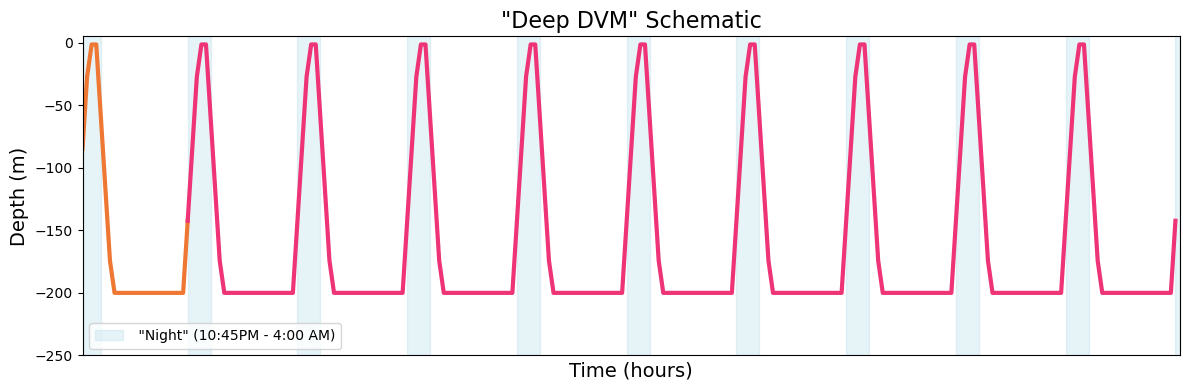

In [109]:
# Define zoom limits in hours
zoom_xlim = (95 * 24, 105 * 24)  # From day 95 to day 105, in hours
zoom_ylim = (-250, 5)            # Focus on depths between -250 m and 5 m

# Plot the zoomed DVM pattern with day/night shading
deep_dvm_zoom(
    hours_d, depths_d, stage_colors, stage_hour_ranges, 
    dvm_start_hour=dvm_start_hour, zoom_xlim=zoom_xlim, zoom_ylim=zoom_ylim,
    save_path="zoomed_dvm_deep.png"

)

In [139]:
def multi_dvm_zoom(hours_s, depths_s, hours_r, depths_r, hours_d, depths_d, 
                   stage_colors, stage_hour_ranges, dvm_start_hour, 
                   zoom_xlim=(95 * 24, 105 * 24), zoom_ylim=(-250, 5), 
                   sunrise_hour=4, sunset_hour=22 + 45 / 60, save_path=None, legend_row=2):
    """
    Creates a multi-row plot with zoomed-in views of Standard, Deep, and Reverse DVM patterns, with the legend on one row.

    Parameters:
    - hours_s, depths_s: Time and depths for Standard DVM.
    - hours_r, depths_r: Time and depths for Reverse DVM.
    - hours_d, depths_d: Time and depths for Deep DVM.
    - stage_colors, stage_hour_ranges: Color and stage information for the DVM patterns.
    - dvm_start_hour: Starting hour for DVM.
    - zoom_xlim: Tuple (min_hour, max_hour) for the x-axis zoom.
    - zoom_ylim: Tuple (min_depth, max_depth) for the y-axis zoom.
    - sunrise_hour, sunset_hour: Sunrise and sunset times in hours (e.g., 4 and 22.75).
    - save_path: Optional path to save the output plot.
    - legend_row: Index of the row (0-based) where the legend should appear.
    """
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

    # Reorder patterns as Standard, Deep, Reverse
    patterns = [("Standard DVM", hours_s, depths_s, "Standard DVM"),
                ("Deep DVM", hours_d, depths_d, "Modified DVM when < 25% SIC"),
                ("Reverse DVM", hours_r, depths_r, "Modified DVM when > 25% SIC")]

    for i, (ax, (label, hours, depths, title)) in enumerate(zip(axes, patterns)):
        # Add night shading
        start_hour = int(zoom_xlim[0])
        end_hour = int(zoom_xlim[1])
        current_block_start = None

        for hour in range(start_hour, end_hour):
            day_fraction = hour % 24
            if not (sunrise_hour <= day_fraction < sunset_hour):  # Nighttime
                if current_block_start is None:
                    current_block_start = hour  # Start of a night block
            else:  # Daytime
                if current_block_start is not None:
                    ax.axvspan(current_block_start / 24, hour / 24, color='lightblue', alpha=0.3)
                    current_block_start = None
        if current_block_start is not None:
            ax.axvspan(current_block_start / 24, end_hour / 24, color='lightblue', alpha=0.3)

        # Plot DVM profile
        for stage, (start_hour, end_hour) in stage_hour_ranges.items():
            if end_hour < zoom_xlim[0] or start_hour > zoom_xlim[1]:
                continue

            start_idx = max(0, np.searchsorted(hours, max(start_hour, zoom_xlim[0])))
            end_idx = min(len(hours), np.searchsorted(hours, min(end_hour, zoom_xlim[1])))

            ax.plot(
                hours[start_idx:end_idx] / 24, depths[start_idx:end_idx],
                color=stage_colors[stage], linewidth=3,
                label=f"{stages[stage]['label']} ({start_hour}-{end_hour} h)"
            )

        # Add row-specific title
        ax.set_title(f"{title}", fontsize=16)

        # Set axis limits
        ax.set_xlim(zoom_xlim[0] / 24, zoom_xlim[1] / 24)  # Convert hours to days
        ax.set_ylim(zoom_ylim)

        # Set axis labels
        ax.set_ylabel("Depth (m)", fontsize=14)

        # Add legend only on the specified row
        if i == legend_row:
            night_patch = plt.Rectangle((0, 0), 1, 1, color='lightblue', alpha=0.3, label='Night (10:45 PM - 4:00 AM)')
            ax.legend(handles=[night_patch], loc='lower left', fontsize=10)

        # Remove x-axis ticks except for the last row
        if ax != axes[-1]:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # Shared x-axis label
    axes[-1].set_xlabel("Time (days)", fontsize=14)

    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
        print(f"Multi-row DVM zoom plot saved to {save_path}")

    plt.show()

Multi-row DVM zoom plot saved to multi_row_dvm_plot.png


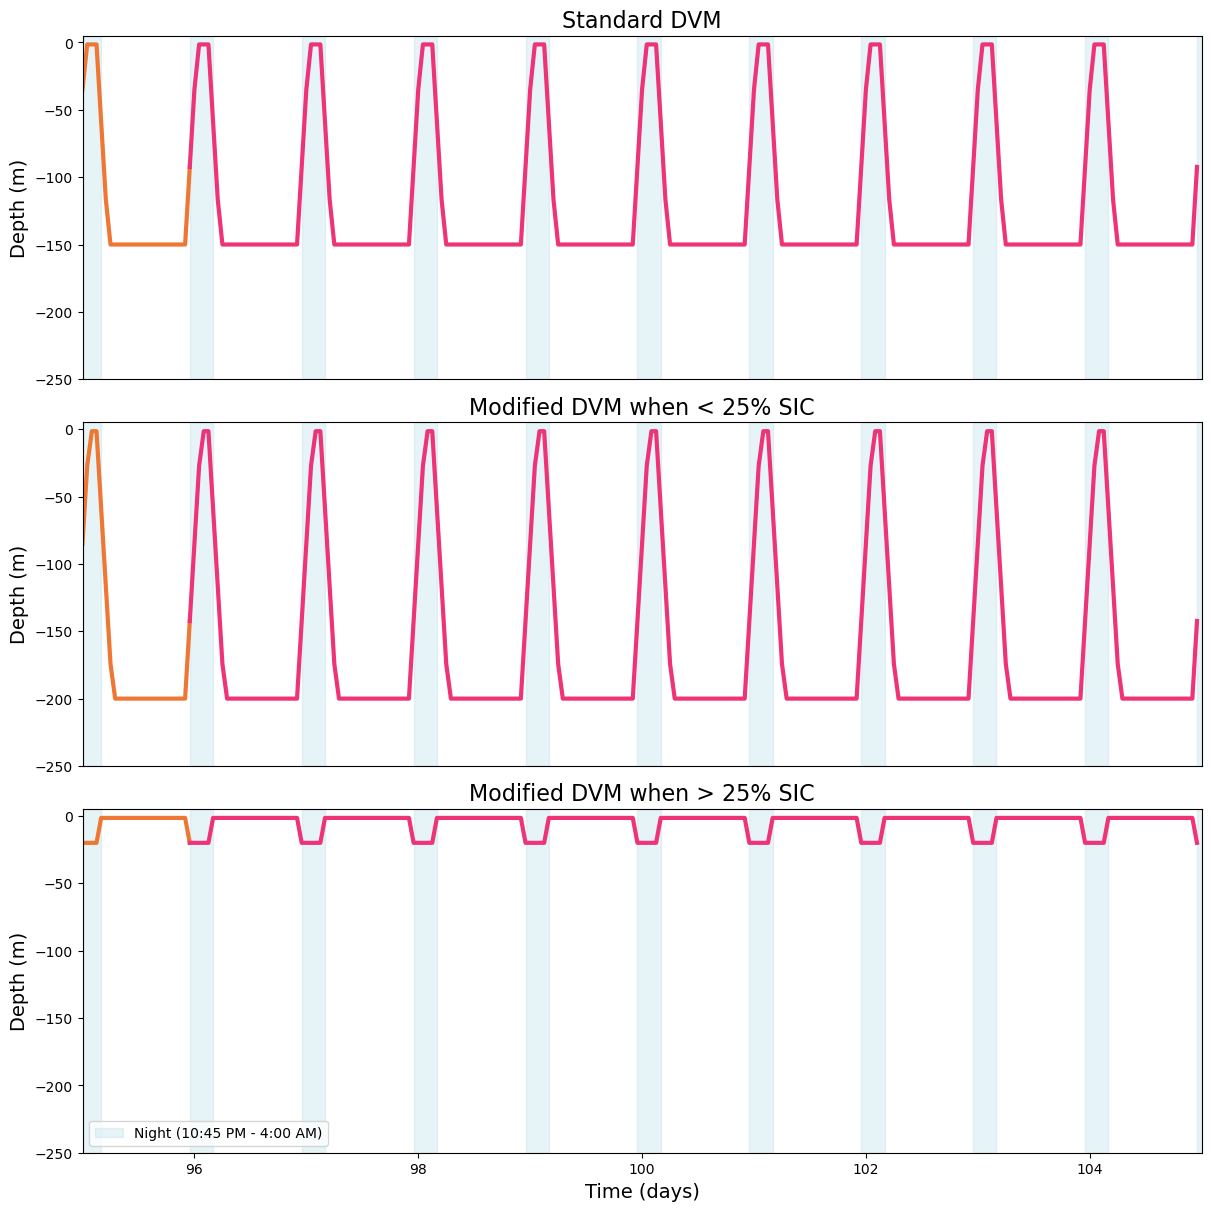

In [140]:
# Generate the profiles
hours_s, depths_s = generate_vertical_profile_data_dvm(duration=180)  # Standard DVM
hours_r, depths_r = generate_vertical_profile_reverse_dvm(duration=180)  # Reverse DVM
hours_d, depths_d = generate_vertical_profile_deep_dvm(duration=180)  # Deep DVM

# Define sunrise and sunset hours
sunrise_hour = 4  # 4:00 AM
sunset_hour = 22 + 45 / 60  # 10:45 PM

# Define zoom limits for days and depths
zoom_xlim = (95 * 24, 105 * 24)  # From day 95 to day 105 (in hours)
zoom_ylim = (-250, 5)            # From -250 m to 5 m (depth range)

# Create the multi-row DVM plot
multi_dvm_zoom(
    hours_s, depths_s, hours_r, depths_r, hours_d, depths_d,
    stage_colors, stage_hour_ranges,
    dvm_start_hour, zoom_xlim, zoom_ylim,
    sunrise_hour, sunset_hour,
    save_path="multi_row_dvm_plot.png"
)